# Include path

In [1]:
import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)

print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")



Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.


# Define Structure

In [2]:
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import MPBSchemeConfigurator
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *


n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "simulation_slab"

## Define the lattice
h_slab = ScriptParam("h_slab", 0.5)
block_size = ScriptParamVector3(1,1,"h_slab", 1,1,0.5)
h_supercell = 4

lattice = Lattice(type="TXY", size=(1,1,h_supercell))
centers = lattice.get_centers()
k_points = lattice.get_high_symmetry_k_points(True)

## Define the geometry

radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
bulk = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": block_size, "material": InP})
hole1 = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": h_slab, "material": air})
hole2 = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": h_slab, "material": air})
photonic_crystal = PhotonicCrystal(atoms=[bulk, hole1, hole2], lattice=lattice)

## Define the simulation

configuration_options_optimization = dict(
    resolution=32,
    num_bands=8,
    k_points=[mp.Vector3(0, 0, 0)],
    k_point_interpolation_factor=None, 
)
mpb_config_opt = MPBSchemeConfigurator(photonic_crystal, ["zeven", "zodd"], **configuration_options_optimization)
script_opt = mpb_config_opt.get_scheme_config(join_newline=True)

configuration_options_unoptimized = dict(
    resolution=32,
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=20, 
)

mpb_config_unoptimized = MPBSchemeConfigurator(photonic_crystal, ["zeven", "zodd"], **configuration_options_unoptimized)
script_unoptimized = mpb_config_unoptimized.get_scheme_config(join_newline=True)


Epsilon of InP:  9.61
Found script param: size with value: (vector3 1 1 h_slab)
Found script param: radius with value: r1
Found script param: height with value: h_slab
Found script param: radius with value: r2
Found script param: height with value: h_slab
COMMANDS ['(define-param h_slab 0.5)', '(define-param r1 0.3)', '(define-param r2 0.2)']
COMMANDS ['(define-param h_slab 0.5)', '(define-param r1 0.3)', '(define-param r2 0.2)']


## Print Script

In [3]:
# Script used in optimization
print(script_opt)

(set! num-bands 8)
(set! resolution 32)
(set! k-points (list (vector3 0.0 0.0 0.0)))

(define-param h_slab 0.5)
(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1 1 4) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1 1 h_slab))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height h_slab)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height h_slab)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-field)
    (output-field-to-file -1 (string-append (get-filename-prefix)"e."))
)


(define (output-nonbloch-hfield which-band)
    (get-hf

In [4]:
## script used in single run 
print(script_unoptimized)

(set! num-bands 8)
(set! resolution 32)
(set! k-points (list (vector3 0.5 0.0 0.0) (vector3 0.0 0.0 0.0) (vector3 0.3333333333333333 0.3333333333333333 0.0) (vector3 0.5 0.0 0.0)))
(set! k-points (interpolate 20 k-points))
(define-param h_slab 0.5)
(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1 1 4) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1 1 h_slab))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height h_slab)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height h_slab)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-f

# Run Single, unoptimized

In [5]:
from sources.mpi_differential_evolution import MPIDiffEvoSimulation
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer
import matplotlib.pyplot as plt
# Create your Simulation instance.
sim_single = Simulation(simulation_name=name + "_unoptimized",
                 script=script_unoptimized,
                 log_level = Simulation.WARNING)

#sim_single.run_hpc_lsf(mpb_command_line_params={"r1":0.20, "r2":0.3}, num_procs=32, span_option="block", span_value=8)
eps = sim_single.load_epsilon()

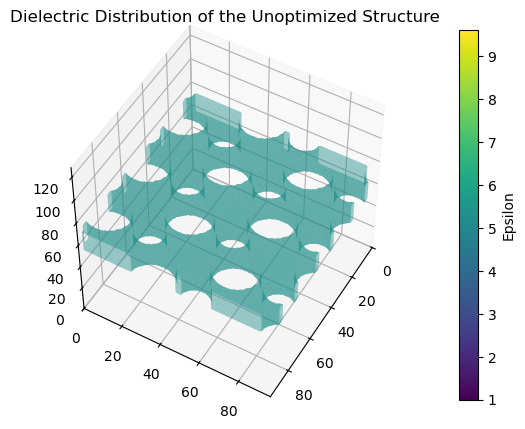

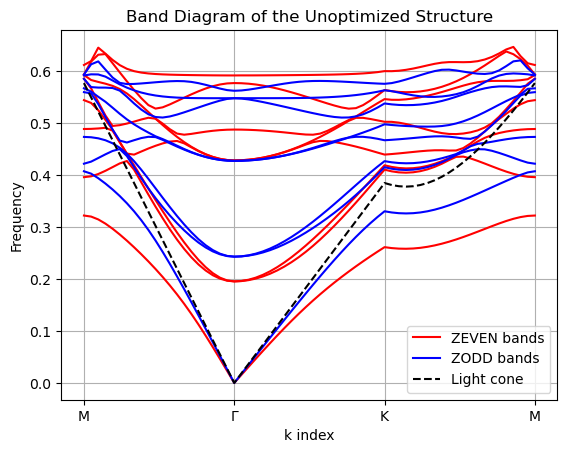

In [6]:

viewer = SimulationViewer(sim_single)
viewer.plot_epsilon_3d(conversion_options={"rectify": True, "periods": (3,3,1)}, alpha = 0.5)
viewer.rotate_fig(30,50)
plt.title("Dielectric Distribution of the Unoptimized Structure")
viewer.show()
viewer.newfig()
viewer.plot_band_diagram("zeven", colors = "red", k_points_path=k_points)
viewer.plot_band_diagram("zodd", colors = "blue", k_points_path=k_points)
df = viewer.simulation.load_frequency_data("zodd")
viewer.plot_light_cone(df)
plt.title("Band Diagram of the Unoptimized Structure")
viewer.show()

# Optimization

## Run

In [7]:
print(script_opt)

(set! num-bands 8)
(set! resolution 32)
(set! k-points (list (vector3 0.0 0.0 0.0)))

(define-param h_slab 0.5)
(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1 1 4) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1 1 h_slab))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height h_slab)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height h_slab)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-field)
    (output-field-to-file -1 (string-append (get-filename-prefix)"e."))
)


(define (output-nonbloch-hfield which-band)
    (get-hf

In [8]:
# Instantiate the MPI optimization wrapper.
np = 32
pop = np//2
simulation_name_opt = name + "_optimization"
optimizer = MPIDiffEvoSimulation(simulation_name = simulation_name_opt, scheme_script= script_opt, maxiter=20,  param_names=["r1", "r2"], 
                                 param_bounds=[(0.05, 0.15), (0.2, 0.4)], polarization="zodd", 
                                 de_options={"strategy": "rand1bin", "popsize": pop}, 
                                 bands=[6,7,8])
# Submit the LSF job.


In [9]:
submission_info = optimizer.submit_lsf_job(nprocs=np, walltime="00:30", queue="fotonano", span_option="block", span_value = 16)
print("Submission info:", submission_info)

LSF job script written to: simulation_slab_optimization/simulation_slab_optimization_lsf_job.sh
Job submitted successfully. Submission output:
Job <24277657> is submitted to queue <fotonano>.

Waiting for job 24277657 to finish...


Waiting for LSF job: 0sec [00:00, ?sec/s, Job status: PEND, Elapsed: 0 sec]

Waiting for LSF job: 1300sec [21:48,  1.01s/sec, Job status: DONE, Elapsed: 1308 sec]

Job finished.
Submission info: Job <24277657> is submitted to queue <fotonano>.



## Plot Row Data

Log file path: simulation_slab_optimization/simulation_slab_optimization.log
The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


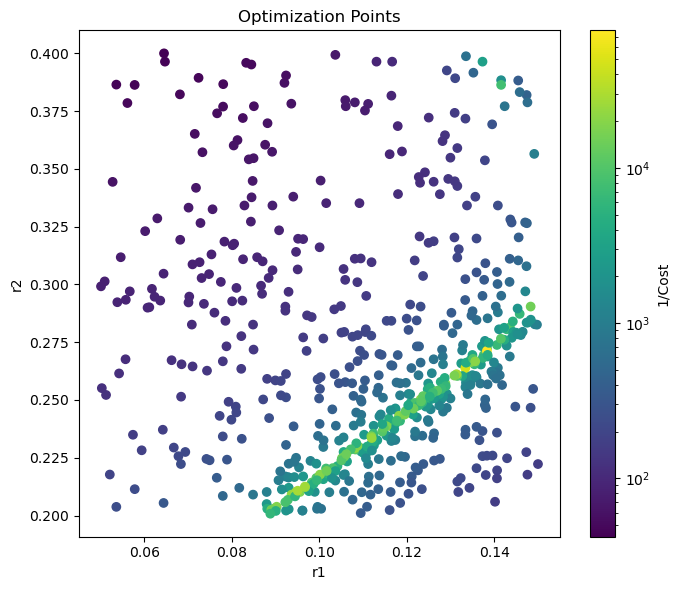

In [10]:
log_file_path_opt = optimizer.log_file
print("Log file path:", log_file_path_opt)
optimizer.plot_optimization_points( log_file_path=log_file_path_opt, use_logscale=True, levels = 100, points_only=True, plot_inverse_cost=True, custom_title="Optimization Points")  

## Analysis

### Find line in parameter space

(0.19, 0.41)

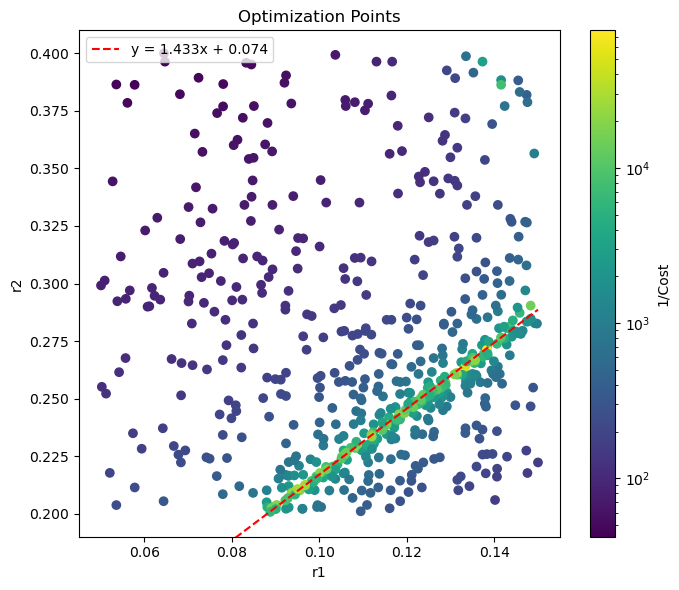

In [16]:
from sources.optimization_data_analyzer import OptimizationDataAnalyzer 
log_file = log_file_path_opt    
analyzer = OptimizationDataAnalyzer(log_file)

# Load all data
analyzer.load_data(debug=True)

# Plot raw data as a scatter with 1/cost
analyzer.plot_raw_data(
    use_logscale=True,
    levels=100,
    points_only=True,
    plot_inverse_cost=True,
    custom_title="Optimization Points"
)

# Overlay the fitted line on the scatter plot
analyzer.plot_fitted_line()
plt.ylim(0.19, 0.41)




###  Dirac frequency along fitted line

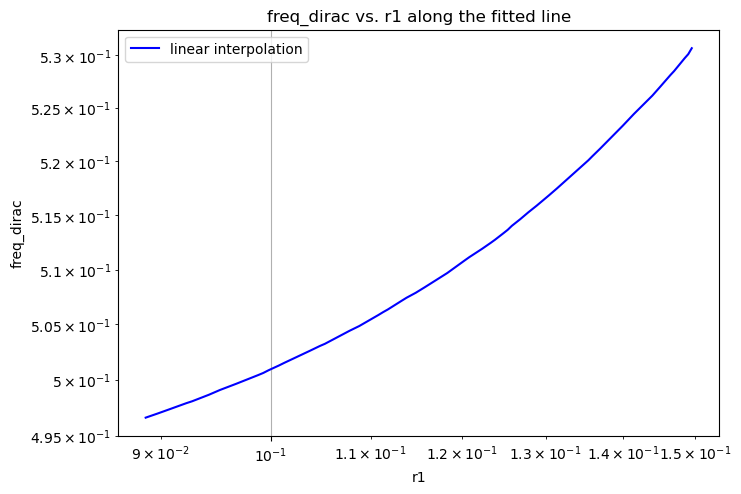

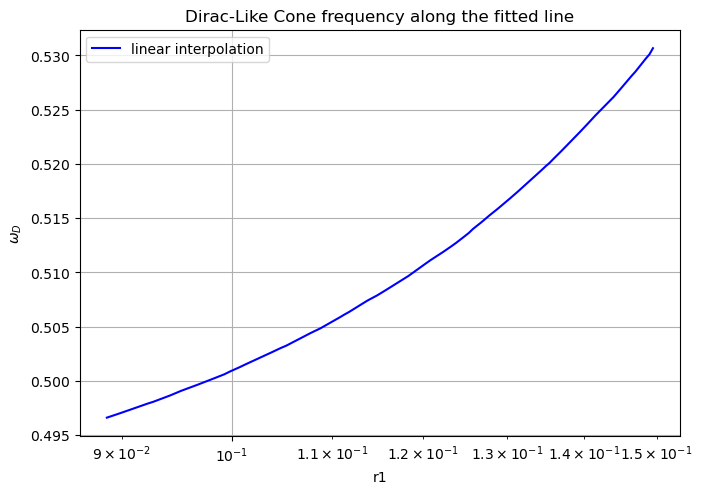

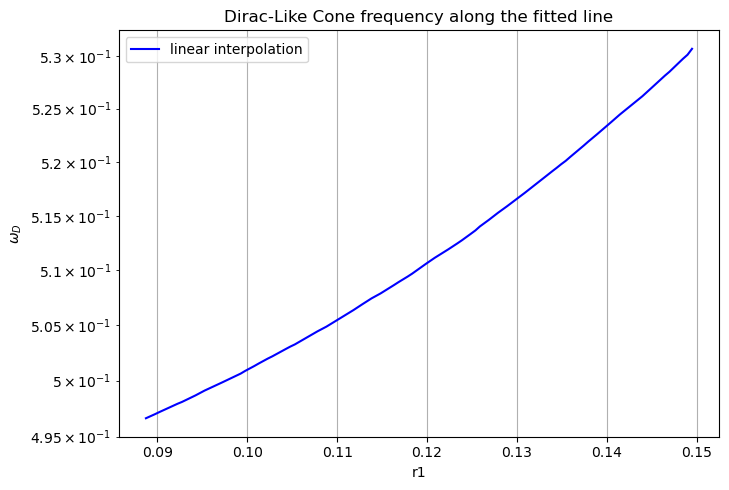

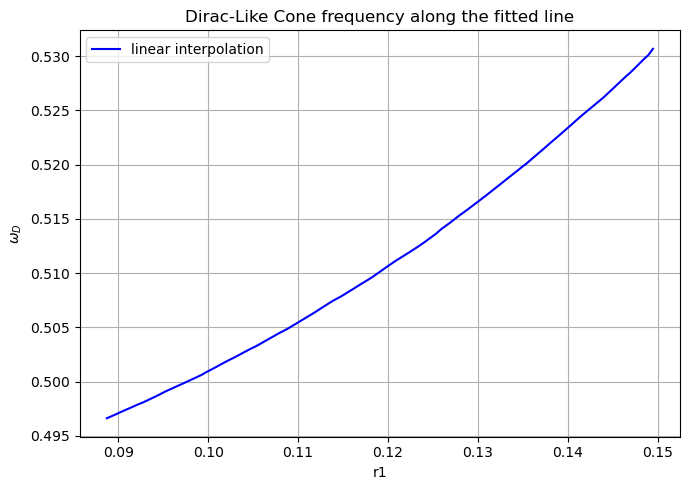

In [14]:

# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title="freq_dirac vs. r1 along the fitted line"
)
plt.xscale("log")
plt.yscale("log")
plt.show()

# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title="Dirac-Like Cone frequency along the fitted line"
)
plt.xscale("log")
plt.ylabel("$\\omega_D$")
plt.xlabel("r1")
plt.show()

# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title="Dirac-Like Cone frequency along the fitted line"
)
plt.yscale("log")
plt.ylabel("$\\omega_D$")
plt.xlabel("r1")
plt.show()


# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title="Dirac-Like Cone frequency along the fitted line"
)
plt.ylabel("$\\omega_D$")
plt.xlabel("r1")
plt.show()







# Optimized Crystal

r1: 0.12 r2: 0.2456985640859301


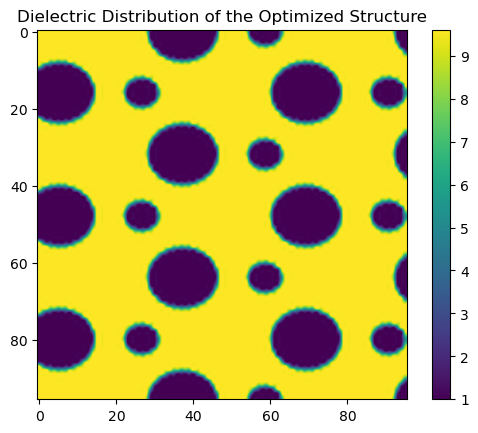

EmptyDataError: No columns to parse from file

<Figure size 640x480 with 0 Axes>

In [ ]:
r1 = 0.12
r2 = analyzer.predict_second_parameter(r1)

print("r1:", r1, "r2:", r2)
sim_single_opt = Simulation(simulation_name=name + "_optimized",
                 script=script_unoptimized,
                 log_level = Simulation.WARNING)
sim_single_opt.run_hpc_lsf(mpb_command_line_params={"r1":r1, "r2":r2}, num_procs=32, span_option="block", span_value=16)



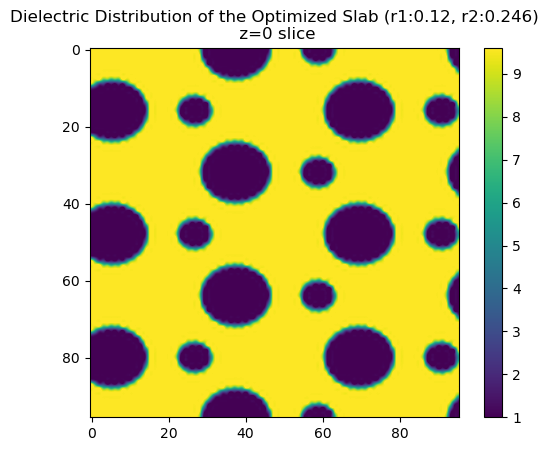

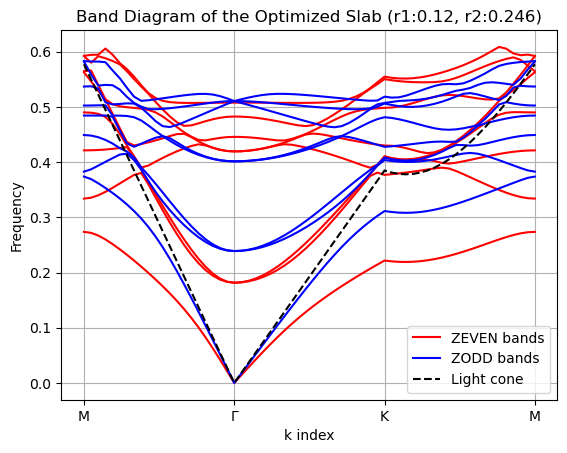

In [24]:
viewer = SimulationViewer(sim_single_opt)
viewer.plot_epsilon_2d(conversion_options={"rectify": True, "periods": 3})
plt.title("Dielectric Distribution of the Optimized Slab (r1:0.12, r2:0.246)\n z=0 slice")
viewer.show()
viewer.newfig()
viewer.plot_band_diagram("zeven", colors = "red", k_points_path=k_points)
viewer.plot_band_diagram("zodd", colors = "blue", k_points_path=k_points)
df = viewer.simulation.load_frequency_data("zodd")
viewer.plot_light_cone(df)
plt.title("Band Diagram of the Optimized Slab (r1:0.12, r2:0.246)")
viewer.show()

In [25]:
k_points

{'k_points_values': [Vector3<0.5, 0.0, 0.0>,
  Vector3<0.0, 0.0, 0.0>,
  Vector3<0.3333333333333333, 0.3333333333333333, 0.0>,
  Vector3<0.5, 0.0, 0.0>],
 'k_points_labels': ['M', 'Γ', 'K', 'M']}

In [31]:
k_point_G_cartesian = mp.Vector3(0.0, 0.0, 0.0)
k_point_X_cartesian = mp.Vector3(0.1, 0.0, 0.0)
k_point_G_reciprocal = lattice.cartesian_to_reciprocal(k_point_G_cartesian)
k_point_X_reciprocal = lattice.cartesian_to_reciprocal(k_point_X_cartesian)
k_points_path_along_x = {
    "k_points_values": [k_point_G_reciprocal, k_point_X_reciprocal],
    "k_points_labels": ["G", "K_X"]
}
print(k_points_path_along_x)


{'k_points_values': [Vector3<0.0, 0.0, 0.0>, Vector3<0.1, 0.05000000000000002, 0.0>], 'k_points_labels': ['G', 'K_X']}


In [32]:
configuration_options_along_x = dict(
    resolution=32,
    num_bands=8,
    k_points=k_points_path_along_x["k_points_values"],
    k_point_interpolation_factor=20, 
    extra_runner_command = "fix-efield-phase output-nonbloch-efield-z output-nonbloch-hfield-y"
)

mpb_config_along_x = MPBSchemeConfigurator(photonic_crystal, ["zodd"], **configuration_options_along_x)
script_optimal_along_x= mpb_config_along_x.get_scheme_config(join_newline=True)
print(script_optimal_along_x)



COMMANDS ['(define-param h_slab 0.5)', '(define-param r1 0.3)', '(define-param r2 0.2)']
(set! num-bands 8)
(set! resolution 32)
(set! k-points (list (vector3 0.0 0.0 0.0) (vector3 0.1 0.05000000000000002 0.0)))
(set! k-points (interpolate 20 k-points))
(define-param h_slab 0.5)
(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1 1 4) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1 1 h_slab))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height h_slab)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height h_slab)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
   

r1: 0.12 r2: 0.2456985640859301


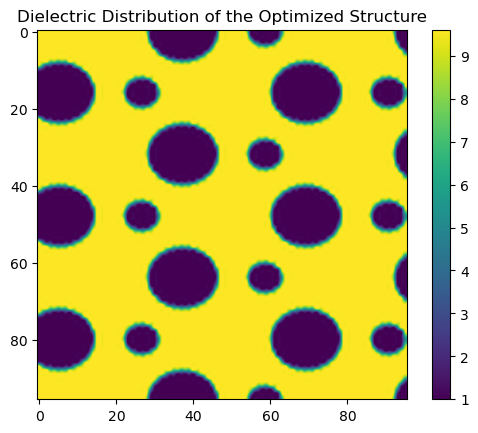

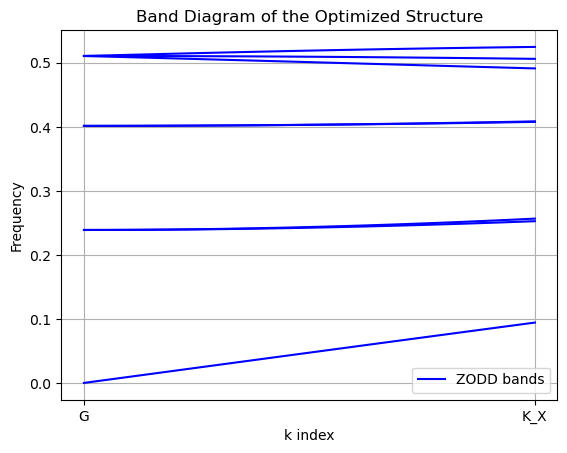

In [36]:
r1 = 0.12
r2 = analyzer.predict_second_parameter(r1)
print("r1:", r1, "r2:", r2)
sim_opt_along_x = Simulation(simulation_name=name + "_opt_along_x",
                 script=script_optimal_along_x,
                 log_level = Simulation.WARNING)
sim_opt_along_x.run_hpc_lsf(mpb_command_line_params={"r1":r1, "r2":r2}, num_procs=32, span_option="block", span_value=16)
viewer = SimulationViewer(sim_opt_along_x)
viewer.plot_epsilon_2d(conversion_options={"rectify": True, "periods": 3})
plt.title("Dielectric Distribution of the Optimized Structure")
viewer.show()
viewer.newfig()
viewer.plot_band_diagram("zodd", colors = "blue", k_points_path=k_points_path_along_x)
plt.title("Band Diagram of the Optimized Structure")
viewer.show()

/zhome/2f/7/202918/phc_nzi/sources/field_analyzer.py:125: RuntimeWarning: invalid value encountered in scalar divide
  return np.emath.sqrt(eps/mu)


K-Index: 1, Band: 6, Eps: (-0+0j), Mu: (-0+0j), Impedance: (nan+nanj), N_eff: 0j
K-Index: 1, Band: 8, Eps: 0.0, Mu: 0.0, Impedance: nan, N_eff: 0.0
K-Index: 2, Band: 6, Eps: 0.030130120816429948, Mu: 0.0002799662678464899, Impedance: 10.374031983927239, N_eff: 0.0029043790170602264
K-Index: 2, Band: 8, Eps: (-0.0265269098092996+0j), Mu: (-0.0003152693575375421+0j), Impedance: (9.172811090701767-0j), N_eff: (-0.0028919062593787868+0j)
K-Index: 3, Band: 6, Eps: 0.05933512682627022, Mu: 0.0008077377062414691, Impedance: 8.57078812275403, N_eff: 0.0069229487389549675
K-Index: 3, Band: 8, Eps: (-0.05402122285261089+0j), Mu: (-0.0008720796253844078+0j), Impedance: (7.8705328406945485-0j), N_eff: (-0.00686373133128858+0j)
K-Index: 4, Band: 6, Eps: 0.0890646055699669, Mu: 0.0014894435268318902, Impedance: 7.732867233814137, N_eff: 0.011517669045254891
K-Index: 4, Band: 8, Eps: (-0.08082408501012082+0j), Mu: (-0.001599591515863567+0j), Impedance: (7.108301699306748-0j), N_eff: (-0.0113703790904

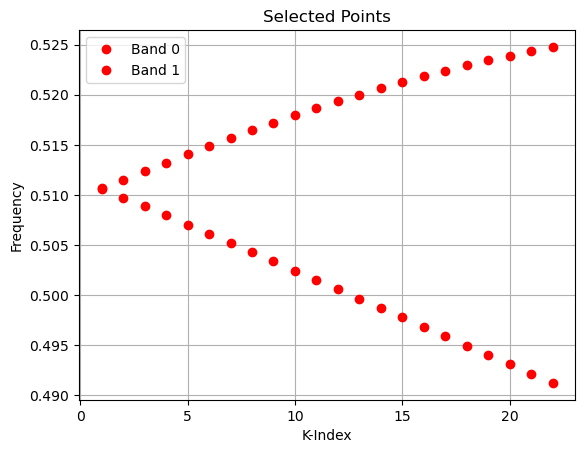

In [37]:
from sources.field_analyzer import FieldAnalyzer

field_analyzer = FieldAnalyzer(sim_opt_along_x, [6,8], "zodd")
result_ds = field_analyzer.get_eps_mu_impedance_neff("z", "y", "2D", True, 3, True)


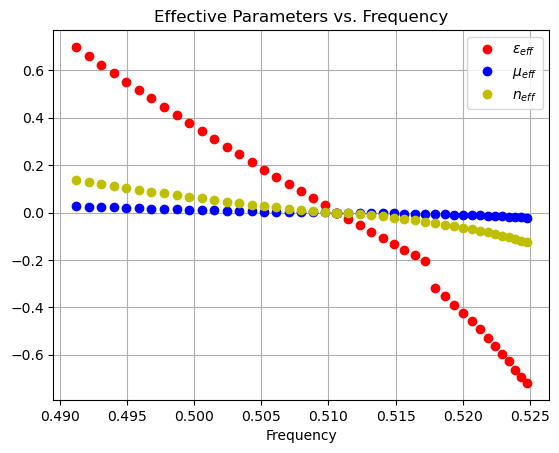

In [39]:
plt.figure()
field_analyzer.plot_eps_vs_freqs()
field_analyzer.plot_mu_vs_freqs()
field_analyzer.plot_neff_vs_freqs()
plt.title("Effective Parameters vs. Frequency")
plt.show()
